# Eigenvalues and Eigenvectors

Eigenvalue decomposition provides a way to characterize the action of a matrix through its eigenvalues and eigenvectors. For a square matrix $A$, an eigenvector $\mathbf{v}$ and its corresponding eigenvalue $\lambda$ satisfy

$$
A\mathbf{v}=\lambda\mathbf{v}.
$$

The eigenvalues determine the scaling factors associated with the corresponding eigenvectors, while the eigenvectors define the directions that remain unchanged under the transformation represented by $A$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

Consider the matrix

$$
A=
\begin{bmatrix}
2 & 1\\
1 & 2
\end{bmatrix}.
$$

In [3]:
A = np.array([[2, 1],
              [1, 2]])
A

array([[2, 1],
       [1, 2]])

The eigenvalues and eigenvectors can be computed using `np.linalg.eig`.

In [4]:
eigenvalues, eigenvectors = np.linalg.eig(A)
eigenvalues, eigenvectors

(array([3., 1.]),
 array([[ 0.70710678, -0.70710678],
        [ 0.70710678,  0.70710678]]))

## Eigenvalue Equation

For a computed eigenpair $(\lambda_i,\mathbf{v}_i)$, the defining relation can be verified directly:

$$
A\mathbf{v}_i=\lambda_i\mathbf{v}_i.
$$

The two sides can be evaluated independently and compared to confirm that the computed eigenvector corresponds to the associated eigenvalue.

In [5]:
A @ eigenvectors[:,0]

array([2.12132034, 2.12132034])

In [6]:
eigenvalues[0] * eigenvectors[:,0]

array([2.12132034, 2.12132034])

Eigenvectors returned by numerical routines can have arbitrary magnitude. Since multiplying an eigenvector by a nonzero scalar does not change its direction, an eigenvector can be normalized as

$$
\hat{\mathbf{v}}_i=\frac{\mathbf{v}_i}{|\mathbf{v}_i|}.
$$

In [7]:
eigenvectors[:,0] / np.linalg.norm(eigenvectors[:,0])

array([0.70710678, 0.70710678])

The resulting vector satisfies

$$
|\hat{\mathbf{v}}_i|=1.
$$

In [8]:
np.linalg.norm(eigenvectors[:,0] / np.linalg.norm(eigenvectors[:,0]))

np.float64(1.0)

## Geometric Interpretation

For a two-dimensional matrix, the eigenvectors can be visualized as vectors originating from the origin. Unlike a general vector, an eigenvector maintains its direction when transformed by the matrix; only its magnitude and possibly its sign are changed according to the corresponding eigenvalue.

The normalized eigenvectors are therefore plotted to visualize the characteristic directions of the matrix.

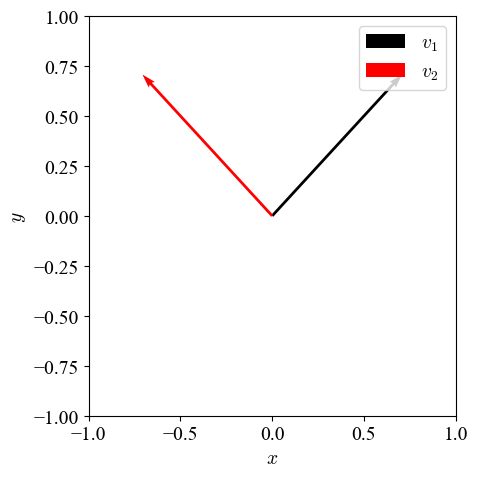

In [9]:
origin = np.zeros(2)
plt.figure(figsize=(5, 5))
plt.quiver(*origin, *eigenvectors[:,0], angles="xy", scale_units="xy", scale=1, color="k", label=r"$v_1$")
plt.quiver(*origin, *eigenvectors[:,1], angles="xy", scale_units="xy", scale=1, color="r", label=r"$v_2$")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

## Eigenvalue Decomposition

If a matrix has a complete set of linearly independent eigenvectors, it can be decomposed as

$$
A=V\Lambda V^{-1},
$$

where $V$ is the matrix whose columns are the eigenvectors and $\Lambda$ is the diagonal matrix containing the corresponding eigenvalues:

$$
\Lambda=
\begin{bmatrix}
\lambda_1 & 0\\
0 & \lambda_2
\end{bmatrix}.
$$

The decomposition can be reconstructed numerically using `V @ np.diag(eigenvalues) @ np.linalg.inv(V)` which should recover the original matrix $A$ up to numerical precision.

In [10]:
V = eigenvectors
V @ np.diag(eigenvalues) @ np.linalg.inv(V)

array([[2., 1.],
       [1., 2.]])

## Symmetric Matrices

Consider the symmetric matrix

$$
K=
\begin{bmatrix}
2 & -1\\
-1 & 2
\end{bmatrix}.
$$

In [11]:
K = np.array([[2, -1],
              [-1, 2]])
K

array([[ 2, -1],
       [-1,  2]])

Its eigenvalues can again be obtained using `np.linalg.eig`.

In [12]:
eigvals, eigvecs = np.linalg.eig(K)
eigvals, eigvecs

(array([3., 1.]),
 array([[ 0.70710678,  0.70710678],
        [-0.70710678,  0.70710678]]))

In this case, the square roots of the eigenvalues are also evaluated,

$$
\omega_i=\sqrt{\lambda_i}.
$$

This transformation is useful when the eigenvalues represent squared frequencies or other quantities whose physical interpretation is obtained through their square roots.

In [13]:
np.sqrt(eigvals)

array([1.73205081, 1.        ])

## Hermitian Matrices

Eigenvalue problems become particularly important for complex-valued Hermitian matrices. A matrix $H$ is Hermitian if

$$
H^\dagger=H.
$$

Consider

$$
H=
\begin{bmatrix}
-5 & -3+4i\\
-3-4i & 5
\end{bmatrix}.
$$

In [14]:
H = np.array([[-5, -3+4j],
              [-3-4j, 5]])
H

array([[-5.+0.j, -3.+4.j],
       [-3.-4.j,  5.+0.j]])

For a Hermitian matrix, `np.linalg.eigh` is preferred over the general-purpose `np.linalg.eig`. The routine returns the eigenvalues together with an orthonormal set of eigenvectors.

In [15]:
E, psi = np.linalg.eigh(H)
E, psi

(array([-7.07106781,  7.07106781]),
 array([[-0.92387953+0.j        ,  0.38268343+0.j        ],
        [-0.22961006-0.30614675j, -0.55432772-0.73910363j]]))

The eigenvectors therefore satisfy

$$
\langle\psi_i|\psi_j\rangle=\delta_{ij},
$$

and each eigenvector can be verified to have unit norm.

In [16]:
np.linalg.norm(psi[:,0] / np.linalg.norm(psi[:,0])), np.linalg.norm(psi[:,1] / np.linalg.norm(psi[:,1]))

(np.float64(1.0), np.float64(1.0))

## Time Evolution

For a time-independent Hamiltonian $H$, the time evolution of a state is governed by the unitary operator

$$
U(t)=e^{-iHt},
$$

where $\hbar=1$ is used here. An initial state $|\Psi(0)\rangle$ therefore evolves according to

$$
|\Psi(t)\rangle=e^{-iHt}|\Psi(0)\rangle.
$$

The matrix exponential can be evaluated directly using `scipy.linalg.expm`.

In [17]:
t = 1
expm(-1j * H * t) @ np.array([1, 0])

array([ 0.70534791+0.50124063j, -0.4009925 +0.30074438j])

## Spectral Decomposition of the Time Evolution

The eigenvalue decomposition of the Hamiltonian provides an alternative way to evaluate the matrix exponential. If

$$
H=\Psi E\Psi^{-1},
$$

where $E$ is the diagonal matrix of eigenvalues, then

$$
e^{-iHt}=\Psi e^{-iEt}\Psi^{-1}.
$$

Since $E$ is diagonal, its exponential is obtained by exponentiating each eigenvalue independently:

$$
e^{-iEt}=\operatorname{diag}\left(e^{-iE_1t},e^{-iE_2t},\ldots\right).
$$

The time-dependent state can therefore be computed as

$$
|\Psi(t)\rangle=\Psi e^{-iEt}\Psi^{-1}|\Psi(0)\rangle.
$$

The result can be compared with the direct matrix-exponential approach to verify the spectral representation numerically.

In [18]:
psi @ np.diag(np.exp(-1j * E * t)) @ np.linalg.inv(psi) @ np.array([1, 0])

array([ 0.70534791+0.50124063j, -0.4009925 +0.30074438j])

## Time-Dependent Probabilities

The components of the evolved state are complex amplitudes. Their corresponding probabilities are obtained from the squared magnitudes,

$$
P_i(t)=|\Psi_i(t)|^2.
$$

Plotting these quantities over time shows how the probability distribution evolves under the Hamiltonian.

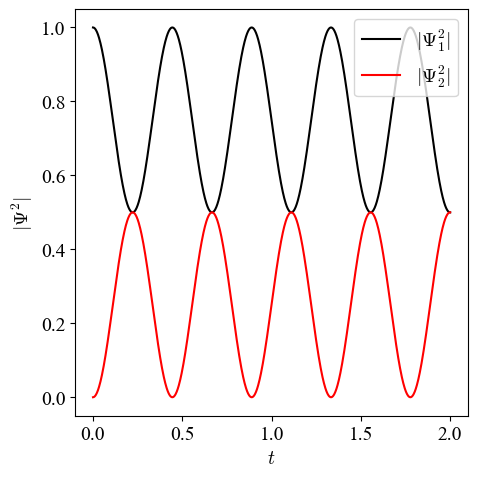

In [19]:
times = np.linspace(0, 2, 1000)
Psi = np.array([psi @ np.diag(np.exp(-1j * E * t)) @ np.linalg.inv(psi) @ np.array([1, 0]) for t in times])
plt.figure(figsize=(5, 5))
plt.plot(times, np.abs(Psi[:,0])**2, "k", label=r"$|\Psi_1^2|$")
plt.plot(times, np.abs(Psi[:,1])**2, "r", label=r"$|\Psi_2^2|$")
plt.xlabel(r"$t$")
plt.ylabel(r"$|\Psi^2|$")
plt.legend()
plt.tight_layout()
plt.show()

## Comparison with an Exact Solution

An analytical solution can be used as an independent reference for the numerical eigenvalue-based evolution. For the present system, define the exact solution as

$$
\Psi_{\mathrm{exact}}(t)=
\begin{bmatrix}
\displaystyle\cos(\omega t) + \frac{5i}{\omega}\sin(\omega t)\displaystyle\\
\displaystyle\frac{-4+3i}{\omega}\sin(\omega t)\displaystyle
\end{bmatrix},
$$

with

$$
\omega=\sqrt{50}.
$$

In [20]:
omega = np.sqrt(50)
exact = np.zeros((len(times), 2), dtype=complex)
exact[:, 0] = np.cos(omega*times) + 5j/omega * np.sin(omega*times)
exact[:, 1] = ((-4 + 3j)/omega) * np.sin(omega*times)

The difference between the eigenvalue-based numerical solution and the analytical solution can then be quantified using the Euclidean norm.

In [21]:
np.linalg.norm(Psi - exact)

np.float64(3.558555826075695e-15)

A small value indicates agreement between the numerical time evolution and the exact solution.